# Linear Regression on Population vs Profit

This notebook loads `PopulationProfit.csv`, visualises the data, fits a linear regression model using **scikit-learn**, and visualises the learned parameters (theta).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

## 1. Load & Explore the Data

In [2]:
df = pd.read_csv('PopulationProfit.csv', header=None, names=['Population', 'Profit'])
print(f'Shape: {df.shape}')
df.describe()

Shape: (97, 2)


,Population,Profit
count,97.000000,97.000000
mean,8.159800,5.839135
std,3.869884,5.510262
min,5.026900,-2.680700
25%,5.707700,1.986900
50%,6.589400,4.562300
75%,8.578100,7.046700
max,22.203000,24.147000


## 2. Visualise the Raw Data

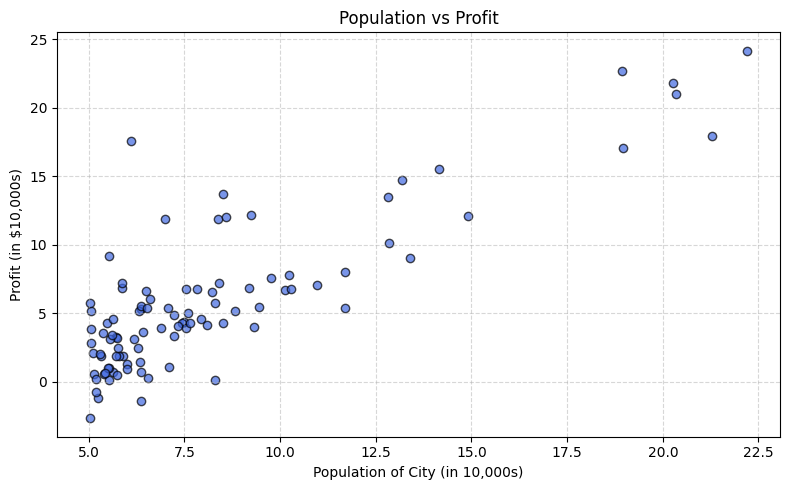

In [3]:
plt.figure(figsize=(8, 5))
plt.scatter(df['Population'], df['Profit'], c='royalblue', edgecolors='k', alpha=0.7)
plt.xlabel('Population of City (in 10,000s)')
plt.ylabel('Profit (in $10,000s)')
plt.title('Population vs Profit')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## 3. Linear Regression with scikit-learn

In [4]:
X = df[['Population']].values   # shape (m, 1)
y = df['Profit'].values          # shape (m,)

model = LinearRegression()
model.fit(X, y)

theta_0 = model.intercept_       # bias / intercept
theta_1 = model.coef_[0]         # slope

print(f'Theta 0 (intercept): {theta_0:.4f}')
print(f'Theta 1 (slope):     {theta_1:.4f}')
print(f'R² score:            {r2_score(y, model.predict(X)):.4f}')
print(f'MSE:                 {mean_squared_error(y, model.predict(X)):.4f}')

Theta 0 (intercept): -3.8958
Theta 1 (slope):     1.1930
R² score:            0.7020
MSE:                 8.9539


## 4. Visualise the Regression Line

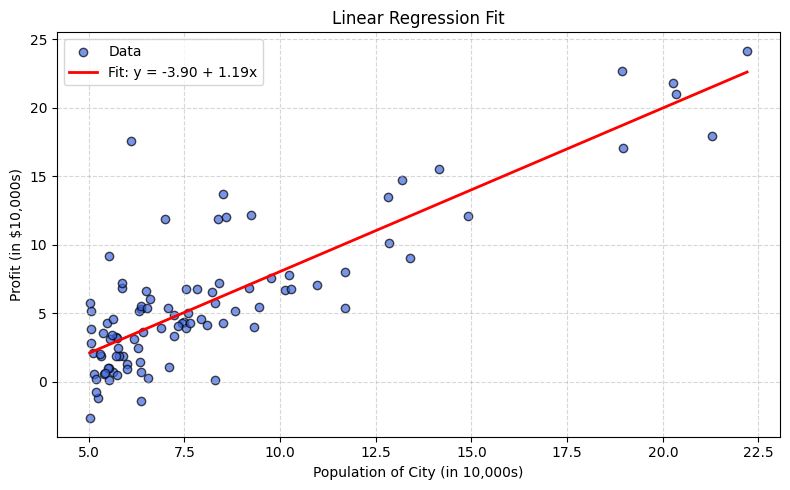

In [5]:
x_line = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
y_line = model.predict(x_line)

plt.figure(figsize=(8, 5))
plt.scatter(X, y, c='royalblue', edgecolors='k', alpha=0.7, label='Data')
plt.plot(x_line, y_line, 'r-', linewidth=2, label=f'Fit: y = {theta_0:.2f} + {theta_1:.2f}x')
plt.xlabel('Population of City (in 10,000s)')
plt.ylabel('Profit (in $10,000s)')
plt.title('Linear Regression Fit')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## 5. Predict on New Data Points

Population (10k)     Predicted Profit ($10k)  
---------------------------------------------
5.0                  2.0694                   
10.0                 8.0346                   
15.0                 13.9997                  
20.0                 19.9649                  
25.0                 25.9301                  


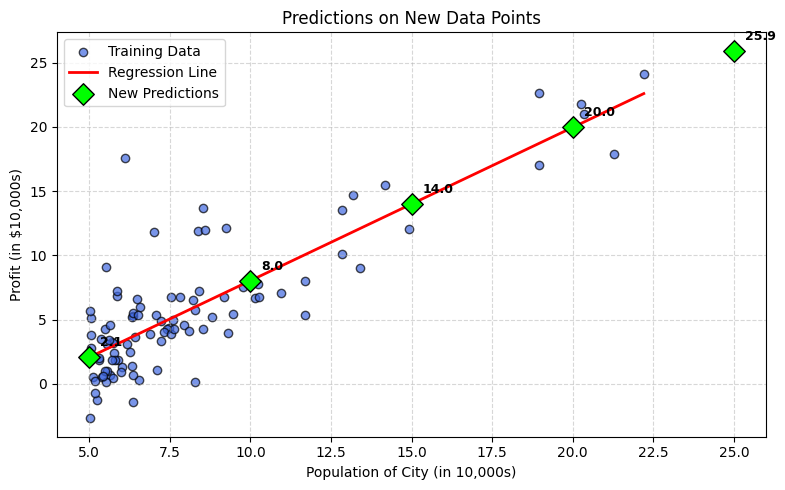

In [12]:
# Define new population values (in 10,000s)
new_populations = np.array([5, 10, 15, 20, 25]).reshape(-1, 1)

# Predict profits
predicted_profits = model.predict(new_populations)

# Display results
col1 = "Population (10k)"
col2 = "Predicted Profit ($10k)"
print(f"{col1:<20} {col2:<25}")
print("-" * 45)
for pop, profit in zip(new_populations.flatten(), predicted_profits):
    print(f"{pop:<20.1f} {profit:<25.4f}")

# Visualise predictions alongside training data
plt.figure(figsize=(8, 5))
plt.scatter(X, y, c="royalblue", edgecolors="k", alpha=0.7, label="Training Data")
plt.plot(x_line, y_line, "r-", linewidth=2, label="Regression Line")
plt.scatter(new_populations, predicted_profits, c="lime", edgecolors="k",
            s=120, zorder=5, marker="D", label="New Predictions")
for pop, profit in zip(new_populations.flatten(), predicted_profits):
    plt.annotate(f"{profit:.1f}", (pop, profit), textcoords="offset points",
                 xytext=(8, 8), fontsize=9, fontweight="bold")
plt.xlabel("Population of City (in 10,000s)")
plt.ylabel("Profit (in $10,000s)")
plt.title("Predictions on New Data Points")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()